## Convert MRDH demand data (from activity-based model used in XCARCITY project) to MaaSSim input data

### Set-up

In [1]:
import pandas as pd
import osmnx as ox
import networkx as nx
import os
from link_demand_to_osm import *
from preprocess_utils import *

In [2]:
# input parameters
study_area = "Nootdorp"
year = 2025
month = 4
day = 1
min_trip_dist = 200 # meter

In [3]:
# Preprocess
date = {'year': year, 'month': month, 'day': day}
nw_type_extensions = {'drive': '', 'bike': '_bike', 'walk': '_walk'}

### Sample the demand data
First, we download the data, compute some additional statistics and select trips (possibly based on a filter)

In [4]:
trips = pd.read_csv('Trips_toy.csv', nrows=100)
pax = pd.read_csv('Persons_toy.csv').sort_values(by='person_id').head(100)
trips

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y
0,22505,68,others,bike,7,17,82338.195312,458177.78125,81147.976562,456129.09375
1,44505,135,others,ebike,7,32,82410.195312,458051.03125,77381.812500,455052.46875
2,69825,212,social,car,8,49,82547.406250,457952.18750,82175.273438,456378.18750
3,71705,218,social,bike,8,48,82503.187500,457959.50000,78432.804688,455119.25000
4,82249,250,school,bike,8,12,82461.382812,458036.43750,77516.078125,451375.40625
...,...,...,...,...,...,...,...,...,...,...
95,937017,2856,school,ride,7,23,81889.695312,457171.00000,82528.296875,451469.78125
96,937409,2857,work,car,7,59,81886.375000,457331.96875,81508.617188,456066.00000
97,939377,2863,work,bike,8,59,81987.468750,457393.62500,81718.984375,454884.62500
98,951097,2899,others,bike,8,37,81932.515625,457274.65625,81923.500000,455074.71875


In [5]:
# Determine eucledian distance and filter based on distance, also filter adults
trips['eucledian_dist'] = trips.apply(lambda row: eucledian_distance(row['origin_coordinate_x'], row['origin_coordinate_y'], row['destination_coordinate_x'], row['destination_coordinate_y']), axis=1)
trips = trips[trips['eucledian_dist'] > min_trip_dist].copy()
pax = pax[pax['person_id'].isin(trips['person_id'])].copy()
pax = pax[pax['age'] >= 18].copy()
trips = trips[trips['person_id'].isin(pax['person_id'])].copy()
processed_demand = pd.DataFrame(index=trips.index)
processed_demand['person_id'] = trips['person_id'].copy()
processed_demand[['purpose', 'activity_mode_model']] = trips[['purpose', 'trip_mode']].copy()
trips

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y,eucledian_dist
0,22505,68,others,bike,7,17,82338.195312,458177.78125,81147.976562,456129.09375,2369.333481
1,44505,135,others,ebike,7,32,82410.195312,458051.03125,77381.812500,455052.46875,5854.571784
2,69825,212,social,car,8,49,82547.406250,457952.18750,82175.273438,456378.18750,1617.392602
3,71705,218,social,bike,8,48,82503.187500,457959.50000,78432.804688,455119.25000,4963.369451
5,103913,316,others,bike,9,30,82428.695312,457977.43750,78882.710938,457977.65625,3545.984382
...,...,...,...,...,...,...,...,...,...,...,...
93,916745,2794,work,bike,7,8,81916.367188,457498.28125,78896.710938,456147.78125,3307.895724
96,937409,2857,work,car,7,59,81886.375000,457331.96875,81508.617188,456066.00000,1321.127489
97,939377,2863,work,bike,8,59,81987.468750,457393.62500,81718.984375,454884.62500,2523.324169
98,951097,2899,others,bike,8,37,81932.515625,457274.65625,81923.500000,455074.71875,2199.955974


In [6]:
# Convert trip coordinates in RD New system to WGS84 coordinates and compute some general trip statistics
processed_demand['origin_wgs84'] = trips.apply(lambda row: coordinate_conversion(row.origin_coordinate_x, row.origin_coordinate_y), axis=1)
processed_demand['dest_wgs84'] = trips.apply(lambda row: coordinate_conversion(row.destination_coordinate_x, row.destination_coordinate_y), axis=1)
processed_demand['eucl_dist'] = trips['eucledian_dist']
processed_demand['treq'] = trips.apply(lambda row: determine_treq(row, date=dict()), axis=1) # determine the required departure time for the trip

### Load network(s)
First, we load the network from OpenStreetMap and finding the corresponding OSM node for each request

In [7]:
# First, we download the network data (incl. skim matrices) for each type (drive, bike, walk), which has already been downloaded from OSM and saved
network_types = determine_preprocessed_network_types(study_area, nw_type_extensions)
for network_type in network_types:
    print(f"Loading {network_type} network data")
    extension = nw_type_extensions[network_type]
    G, skims = load_fleetpy_network(study_area, network_type)
    df = pd.DataFrame()
    df['origin_id'] = processed_demand.apply(lambda row: ox.distance.nearest_nodes(G, row.origin_wgs84[1], row.origin_wgs84[0]), axis=1)
    df['destination_id'] = processed_demand.apply(lambda row: ox.distance.nearest_nodes(G, row.dest_wgs84[1], row.dest_wgs84[0]), axis=1)
    # Now we compute additional trip statistics from the skim matrices based on the found nodes
    df['ttrav'] = df.apply(lambda row: skims['tt'][row.origin_id][row.destination_id], axis=1) # find origin and destination nodes in the graph and compute the shortest path between them based on the travel time matrix
    df['dist'] = df.apply(lambda row: skims['distance'][int(row.origin_id)][int(row.destination_id)], axis=1) # find origin and destination nodes in the graph and compute the shortest path between them based on the distance matrix
    df.columns = [col + extension for col in df.columns]
    processed_demand = pd.concat([processed_demand, df], axis=1)

Loading drive network data
Loading bike network data


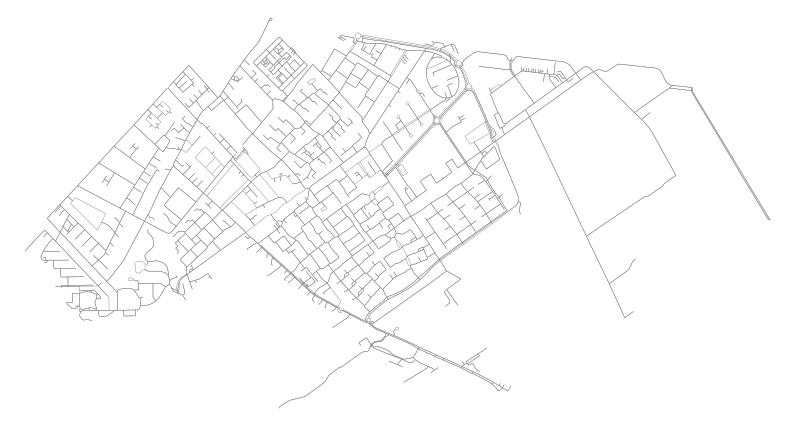

In [8]:
# Plot network
_ = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_linewidth=0.3,
                            show=False, close=False,
                            edge_color='grey', bgcolor='white')

Below, we establish passenger (not trip) data

In [9]:
passengers = pax[['person_id', 'urbanized', 'driving_license', 'age', 'value_of_time', 'age']].copy()
passengers['sex'] = pax.apply(lambda row: "Male" if row.sex == 1 else "Female", axis=1)
passengers['bike_option'] = pax.apply(lambda row: True if row.has_bike + row.has_ebike > 0 else False, axis=1)
passengers['car_option'] = pax.apply(lambda row: True if row.has_car > 0 and row.driving_license > 0 else False, axis=1)
passengers = passengers.rename(columns={'value_of_time': 'VoT'})


### Save demand dataframes (requests and passengers)

In [10]:
# Output path
output_path = "output"

In [11]:
# Save person characterstics to csv
passengers.to_csv(os.path.join(output_path,'passengers.csv'), index=False)
passengers

,person_id,urbanized,driving_license,age,VoT,age,sex,bike_option,car_option
39867,68,3,1,67,1.000000,67,Female,True,False
49896,135,3,1,69,17.284870,69,Male,True,True
79753,212,4,1,75,1.574981,75,Male,True,True
29830,218,4,1,85,15.965388,85,Female,True,False
79754,316,4,1,71,13.390107,71,Female,True,False
...,...,...,...,...,...,...,...,...,...
49903,2794,4,1,59,3.562327,59,Male,True,True
19910,2857,4,1,26,12.566077,26,Male,True,True
49904,2863,4,1,58,2.301255,58,Male,True,False
19911,2899,4,1,73,19.517941,73,Female,True,True


In [12]:
processed_demand.to_csv(os.path.join(output_path,'requests.csv'), index=False)
processed_demand

,person_id,purpose,activity_mode_model,origin_wgs84,dest_wgs84,eucl_dist,treq,origin_id,destination_id,ttrav,dist,origin_id_bike,destination_id_bike,ttrav_bike,dist_bike
0,68,others,bike,"(52.107059693392415, 4.326543858669857)","(52.088491126870736, 4.3096167753397765)",2369.333481,2025-04-01 07:17:49,426,299,82.522960,635.091,741,434,209.34162,1163.009
1,135,others,ebike,"(52.10593007298513, 4.3276216901900115)","(52.07830070101872, 4.254919075844015)",5854.571784,2025-04-01 07:32:12,426,285,215.267493,1630.675,741,404,388.54674,2158.593
2,212,social,car,"(52.105059771355755, 4.329645227516112)","(52.0908657645561, 4.324550546685751)",1617.392602,2025-04-01 08:49:08,426,426,0.000000,0.000,741,741,0.00000,0.000
3,218,social,bike,"(52.10511969543625, 4.328998335623955)","(52.079047154237884, 4.270233023547807)",4963.369451,2025-04-01 08:48:16,426,285,215.267493,1630.675,741,404,388.54674,2158.593
5,316,others,bike,"(52.10527113067465, 4.327907362240642)","(52.1047966767519, 4.276157008527929)",3545.984382,2025-04-01 09:30:45,426,298,100.473360,769.719,741,433,233.57466,1297.637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2794,work,bike,"(52.10089764811014, 4.320533099603238)","(52.08835416741779, 4.276769847137182)",3307.895724,2025-04-01 07:08:45,426,285,215.267493,1630.675,741,1088,314.56026,1747.557
96,2857,work,car,"(52.09939907864013, 4.3201311077623705)","(52.08797211156468, 4.314891652388505)",1321.127489,2025-04-01 07:59:19,426,436,43.143360,339.744,741,704,200.49768,1113.876
97,2863,work,bike,"(52.099966513990296, 4.321593089593189)","(52.07738325831073, 4.318214386495757)",2523.324169,2025-04-01 08:59:34,426,294,136.700027,1041.419,741,717,294.63426,1636.857
98,2899,others,bike,"(52.0988901193547, 4.320816691574406)","(52.07911861385666, 4.321156556862492)",2199.955974,2025-04-01 08:37:57,426,298,100.473360,769.719,741,433,233.57466,1297.637


In [13]:
pax

,person_id,household_id,age,PNUM,sex,pemploy,pstudent,ptype,driving_license,education,...,num_joint_tours,non_mandatory_tour_frequency,num_non_mand,num_escort_tours,num_eatout_tours,num_shop_tours,num_maint_tours,num_discr_tours,num_social_tours,num_non_escort_tours
39867,68,55,67,1,2,3,3,5,1,4,...,0,1,2,0,0,0,0,2,0,2
49896,135,108,69,1,1,3,3,5,1,2,...,1,8,1,0,0,0,2,0,0,1
79753,212,161,75,1,1,3,3,5,1,3,...,0,10,2,0,0,0,1,0,1,2
29830,218,166,85,2,2,3,3,5,1,4,...,0,17,3,0,0,1,0,2,0,3
79754,316,241,71,1,2,3,3,5,1,4,...,0,16,2,0,0,2,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49903,2794,1668,59,2,1,1,3,1,1,4,...,0,2,1,0,0,0,0,0,1,1
19910,2857,1695,26,2,1,1,3,1,1,3,...,0,0,0,0,0,0,0,0,0,0
49904,2863,1698,58,2,1,1,3,1,1,4,...,0,0,0,0,0,0,0,0,0,0
19911,2899,1715,73,1,2,3,3,5,1,2,...,0,8,1,0,0,0,1,0,0,1
